## Laboratorio 1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  




## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [ ]:
#Para contar uantos hay en la isla de torgersen

df_torgersen = df[df.isla == 'Torgersen']
print('Pinguinos de la isla de Torgersen:', df_torgersen.shape[0])

Pinguinos de la isla de Torgersen: 47


In [ ]:
print("La profundidad del pico maximo de la isla Torgersen es de:", df_torgersen['profundidad_pico (mm)'].max(), "mm")
print("La profundidad del pico minimo de la isla Torgersen es de:", df_torgersen['profundidad_pico (mm)'].min(), "mm")

La profundidad del pico maximo de la isla Torgersen es de: 21.5 mm
La profundidad del pico minimo de la isla Torgersen es de: 15.9 mm


2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

In [ ]:
Mc = np.argmax(df['masa_corporal (g)'])
print("El índice del pingüino con mayor masa corporal es:", Mc)

penguin_max_mass_row = df.loc[Mc]
print(df.loc[Mc])
#el df.loc me da datos de ese indice (estudiar)

El índice del pingüino con mayor masa corporal es: 231
especie                  Gentoo
isla                     Biscoe
longitud_pico (mm)         49.2
profundidad_pico (mm)      15.2
longitud_aleta (mm)       221.0
masa_corporal (g)        6300.0
genero                     Male
Name: 231, dtype: object


In [ ]:
prnpenguin_masa_max = df.loc[Mc]
print("El pinguino mas gordo es de la isla:", penguin_masa_max['isla'])
print("Pertenece a la siguiente especie:", penguin_masa_max['especie'])
print("Y su genero es:", penguin_masa_max['genero'])

El pinguino mas gordo es de la isla: Biscoe
Pertenece a la siguiente especie: Gentoo
Y su genero es: Male


In [ ]:
3. ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

In [ ]:
df_Gentoo = df[(df['genero'] == 'Male') & (df['especie'] != 'Gentoo')] #Estudiar este codigo y por que funciona

masamedia = df_Gentoo['masa_corporal (g)'].mean()

print("La masa corporal media de los pingüinos macho que no son de la especie Gentoo es:",masamedia, "g")

La masa corporal media de los pingüinos macho que no son de la especie Gentoo es: 4010.2803738317757 g


4.Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. Ayuda: utilice la funcion hist()

In [100]:
pico_media = df['longitud_pico (mm)'].mean()
pico_desviacion= df['longitud_pico (mm)'].std()
print(pico_media)
print(pico_desviacion)

43.992792792792805
5.468668342647559


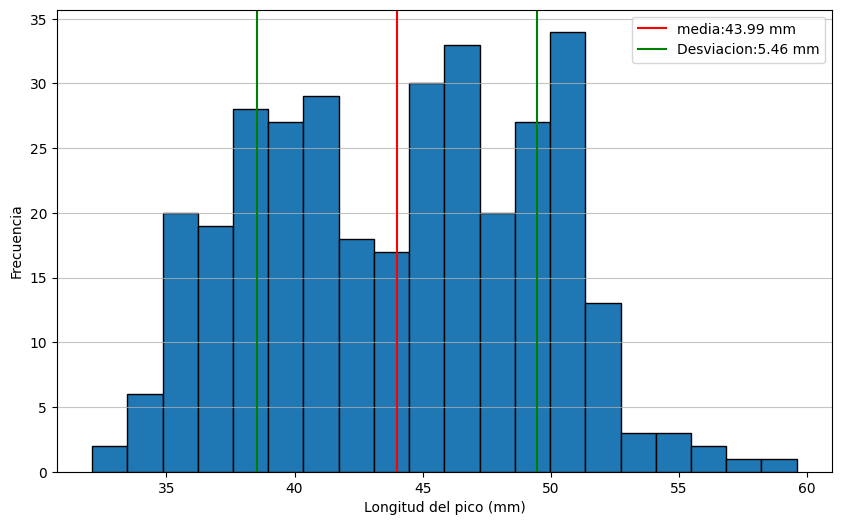

In [108]:
import matplotlib.pyplot as plt

pico_media = df['longitud_pico (mm)'].mean()
pico_desviacion= df['longitud_pico (mm)'].std()

plt.figure(figsize=(10, 6))
plt.hist(df['longitud_pico (mm)'], bins=20, edgecolor='black')
plt.axvline(pico_media, color='red', label= "media:43.99 mm") # Esto me pone una raya para la media
plt.axvline(pico_media + pico_desviacion, color='green', label= "Desviacion:5.46 mm" ) # Son 2 para saber que la media es mas menos
plt.axvline(pico_media - pico_desviacion, color='green')
plt.xlabel('Longitud del pico (mm)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

### 5. ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.

In [97]:
x=df["isla"].unique()
y=df["especie"].unique()
print("Las islas presentes en el conjunto de datos son:", x)
print("Las especies presentes en el conjunto de datos son:", y)

Las islas presentes en el conjunto de datos son: ['Torgersen' 'Biscoe' 'Dream']
Las especies presentes en el conjunto de datos son: ['Adelie' 'Chinstrap' 'Gentoo']


In [ ]:
##df.[].value_counts me da el numero de valores para cada isla

frecuencia_islas = df['isla'].value_counts()
prnpenguin_masa_maxrint('Frecuencia de las islas:')
print(frecuencia_islas)

frecuencia_especie = df['especie'].value_counts()
print('Frecuencia de las especies:')
print(frecuencia_especie)

Frecuencia de las islas:
isla
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

Frecuencia de las especies:
especie
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


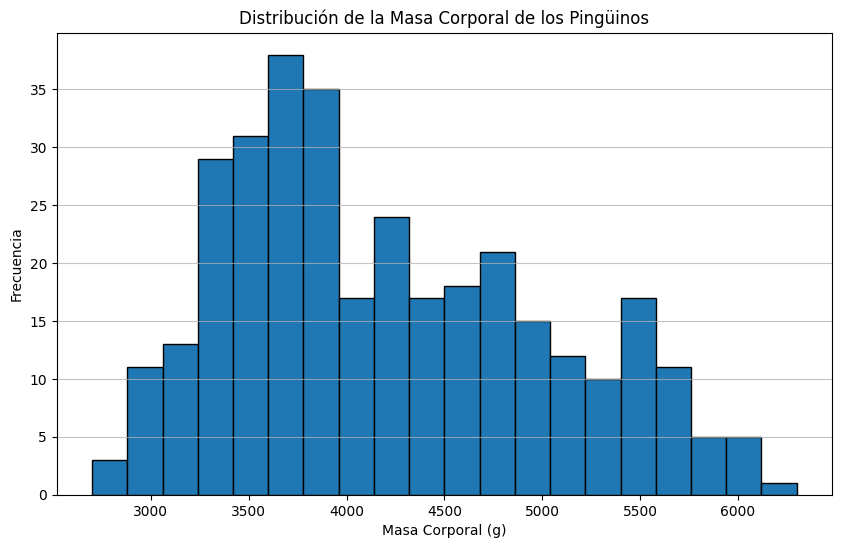

In [101]:

plt.figure(figsize=(10, 6))
plt.hist(df['masa_corporal (g)'], bins=20, edgecolor='black')
plt.title('Distribución de la Masa Corporal de los Pingüinos')
plt.xlabel('Masa Corporal (g)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

MUY BIEN NOTA 5.0